In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('SpotifyFeatures.csv')

features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'popularity']
df_pop= df[df['popularity'] >= 85].copy()
print(f"~*~ first rows of the dataset (popular): \n{df_pop.head()}")
print(f"\n~*~ statistics of columns (popular): \n{df_pop[features].describe()}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_pop[features])
print(f"\n~*~ scaled data (filtered): {df_pop.shape}")

~*~ first rows of the dataset (popular): 
      genre    artist_name                                track_name  \
9026  Dance  Ariana Grande  break up with your girlfriend, i'm bored   
9027  Dance  Ariana Grande                                   7 rings   
9028  Dance         Halsey                                Without Me   
9029  Dance  Ariana Grande                                     needy   
9030  Dance  Ariana Grande                                      NASA   

                    track_id  popularity  acousticness  danceability  \
9026  4kV4N9D1iKVxx1KLvtTpjS          99        0.0421         0.726   
9027  14msK75pk3pA33pzPVNtBF         100        0.5780         0.725   
9028  5p7ujcrUXASCNwRaWNHR1C          97        0.2970         0.752   
9029  1TEL6MlSSVLSdhOSddidlJ          92        0.7800         0.647   
9030  4uTvPEr01pjTbZgl7jcKBD          91        0.4510         0.747   

      duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
9026       190

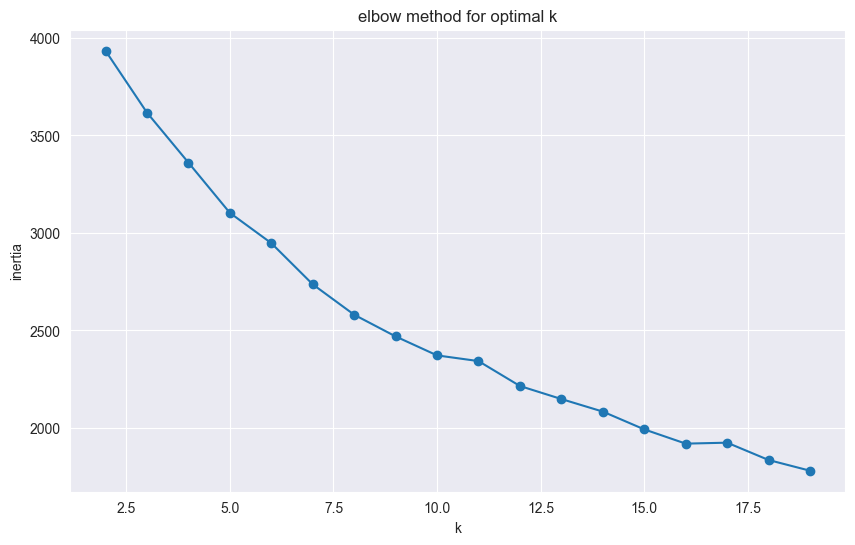

In [16]:
inertia = []
k_range = range(2, 20)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=[10, 6])
plt.plot(k_range, inertia, marker='o')
plt.title('elbow method for optimal k')
plt.xlabel('k')
plt.ylabel('inertia')
plt.grid(True)
plt.show()

In [24]:
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_pop['cluster'] = kmeans.fit_predict(scaled_data)
print("~*~ number of tracks per cluster:")
print(df_pop['cluster'].value_counts().sort_index())

~*~ number of tracks per cluster:
cluster
0    113
1    143
2     71
3     32
4      7
5     51
Name: count, dtype: int64


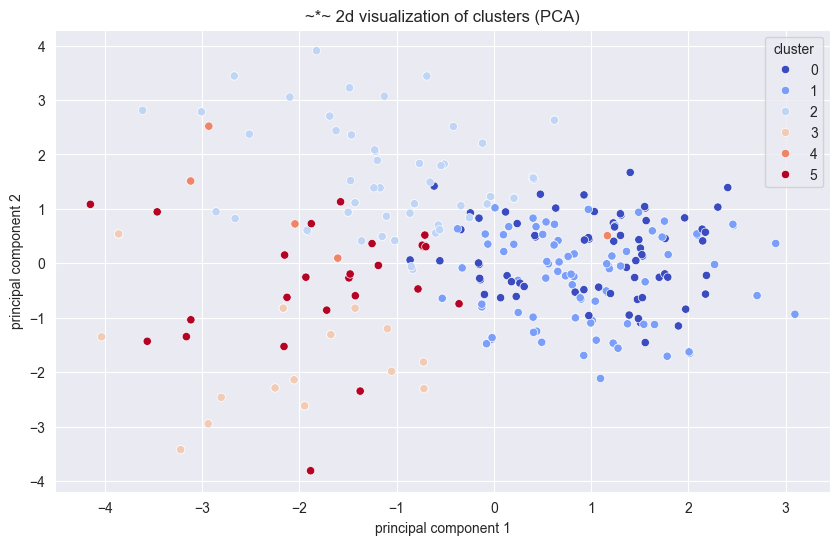

In [26]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
df_pop['pca1'] = pca_data[:, 0]
df_pop['pca2'] = pca_data[:, 1]

plt.figure(figsize=[10, 6])
sns.scatterplot(data=df_pop, x='pca1', y='pca2', hue='cluster', palette='viridis')
plt.title('~*~ 2d visualization of clusters (PCA)')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(title='cluster')
plt.show()


~*~ cluster analysis: mean values of features per cluster 
         danceability    energy  loudness  speechiness  acousticness  \
cluster                                                                
0            0.733106  0.737204 -4.530124     0.100599      0.196998   
1            0.697462  0.698622 -5.265832     0.110634      0.100609   
2            0.612634  0.514070 -6.866789     0.091110      0.481246   
3            0.865313  0.469781 -8.331406     0.351125      0.121346   
4            0.734714  0.600857 -8.347857     0.121543      0.172130   
5            0.824137  0.487490 -8.488235     0.156349      0.228559   

         instrumentalness  liveness   valence       tempo    duration_ms  \
cluster                                                                    
0                0.000560  0.129556  0.646566  105.495982  193028.566372   
1                0.001173  0.185275  0.424585  144.601685  220575.167832   
2                0.000462  0.143118  0.396211  106.859070  

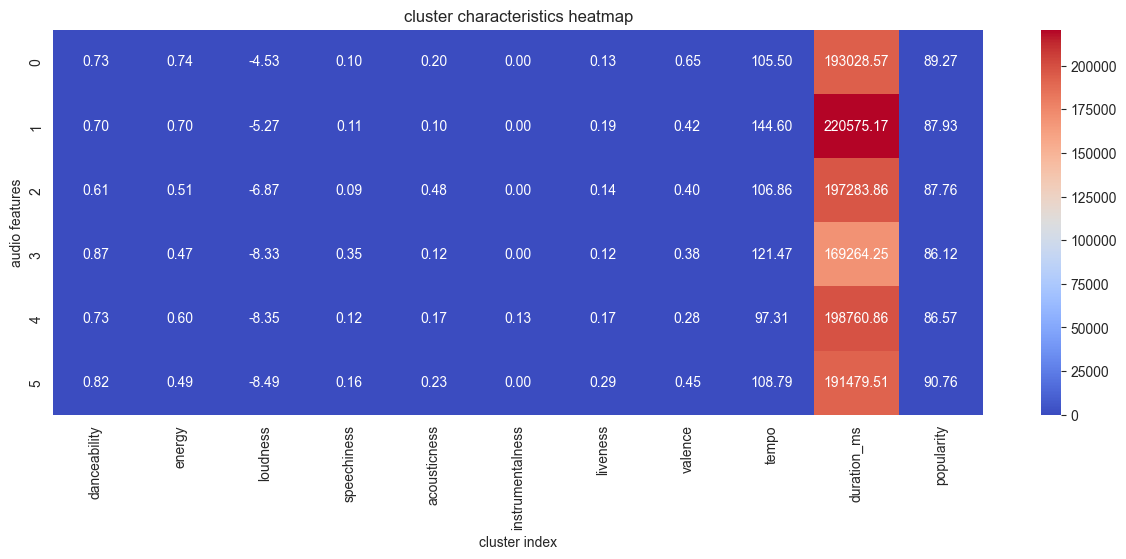

In [30]:
cluster_analysis = df_pop.groupby('cluster')[features].mean()
print(f"\n~*~ cluster analysis: mean values of features per cluster \n{cluster_analysis}")

plt.figure(figsize=[15, 5])
sns.heatmap(cluster_analysis, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('cluster characteristics heatmap')
plt.xlabel('cluster index')
plt.ylabel('audio features')
plt.show()